Here I am working on churn dataset, where the target variable is highly imbalanced with significantly fewer churned customers compared to non-churned customers and I have thought of implementing it with XGBoost and CatBoost
Since the dataset is imbalanced, I used :
    Class weighting using scale_pos_weight
    Oversampling using SMOTE
For XGBoost, I compared hyperparameter tuning approaches using both RandomizedSearchCV and Optuna optimization to determine which method achieved better ROC-AUC performance.
And I have tried tuning the model with randomsearch and optuna for XGBoost to see which one performs better.
Finally, I implemented a soft voting ensemble approach by averaging the prediction probabilities from the tuned XGBoost and CatBoost models to improve overall model generalization and predictive performance.
Model performance was evaluated primarily using ROC-AUC score, cross-validation, confusion matrices, and classification metrics.

In [12]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path(__file__).resolve().parent#Getting the folder where this Python script is located.

df = pd.read_csv(BASE_DIR / "data" / "train.csv")
test_df = pd.read_csv(BASE_DIR / "data" / "test.csv")

# XGBoost with Class weighting using scale_pos_weight and RandomizedsearchCV

In [13]:
y = df['Churn'].map({'No': 0, 'Yes': 1})
test_id = test_df['id']
x= df.drop(columns = ['Churn'],errors='ignore')
#df = df.drop(columns = ['id'],errors='ignore')
test_df =test_df.drop(columns=['id'],errors='ignore')
from sklearn.model_selection import train_test_split
x_train,x_val,y_train,y_val = train_test_split(x,y,test_size = 0.2, random_state = 42)
x_train['TotalCharges'] = np.log1p(x_train['TotalCharges'])
x_val['TotalCharges'] = np.log1p(x_val['TotalCharges'])
test_df['TotalCharges'] = np.log1p(test_df['TotalCharges'])
x_train = x_train.drop(columns=['id'], errors='ignore')
x_val = x_val.drop(columns=['id'], errors='ignore')
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from category_encoders.binary import BinaryEncoder
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
import numpy as np
from xgboost import XGBClassifier
ct_onehot = [ 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract',  'PaymentMethod']
b_encod = [ 'gender', 'Partner', 'Dependents', 
       'PhoneService','PaperlessBilling']
ratio = float(y_train.value_counts()[0]) / y_train.value_counts()[1] #majority/minority
ct = ColumnTransformer(transformers= [("onehot",OneHotEncoder(),ct_onehot),
                                     ("binary", BinaryEncoder(cols=b_encod),b_encod),
                                     ("Scale",StandardScaler(),['MonthlyCharges','tenure'])], remainder ='passthrough')
pipeline1 = Pipeline(steps=[
    ('ct', ct), 
    ('xgb', XGBClassifier(scale_pos_weight=ratio,tree_method='hist', eval_metric='auc'))
])


In [14]:
from sklearn.metrics import accuracy_score
from sklearn.model_selection import RandomizedSearchCV
x_tune = x_train.sample(frac=0.15, random_state=42)# taking only afraction for faster computing 
y_tune = y_train.loc[x_tune.index]
param_dist = {
    'xgb__n_estimators': [200,400,600],
    'xgb__max_depth': [3,4,5,6],
    'xgb__learning_rate': [0.01,0.03,0.05,0.1]
}
random_search = RandomizedSearchCV(
    pipeline1,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring='roc_auc'
)
random_search.fit(x_tune, y_tune)
best_parameters = random_search.best_params_
print("Final Parameters being used:", best_parameters)
best_xgb_model = random_search.best_estimator_
best_xgb_model.fit(x_train,y_train)
y_pred = best_xgb_model.predict(x_val)
y_pred_x = best_xgb_model.predict_proba(x_val)[:,1]
y_pred_proba = best_xgb_model.predict_proba(test_df)[:,1]


Final Parameters being used: {'xgb__n_estimators': 600, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.05}


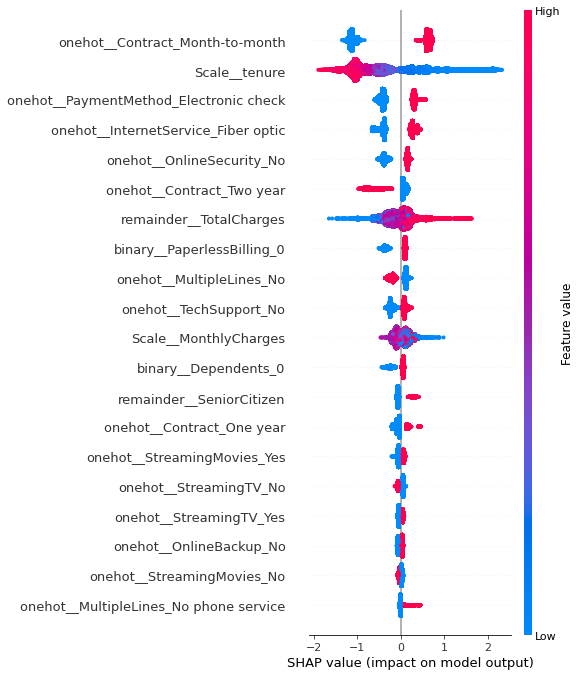

In [20]:
import shap
x_train_transformed = best_xgb_model.named_steps['ct'].transform(x_train)# named_steps means accessing the preprocessing part only, ie , ct and applied transformation only to it.
features_names = best_xgb_model.named_steps['ct'].get_feature_names_out()
x_new_df = pd.DataFrame(
    x_train_transformed,
    columns = features_names
)
xgb_model = best_xgb_model.named_steps['xgb']

explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer.shap_values(x_new_df)

shap.summary_plot(shap_values, x_new_df)

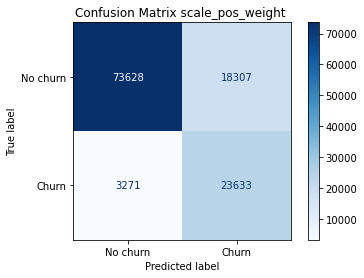

In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix scale_pos_weight ")
plt.show()


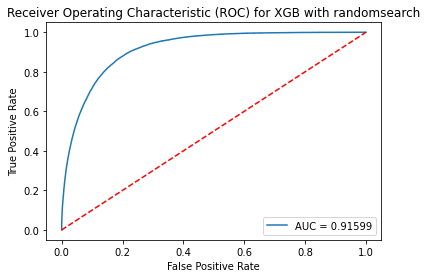

In [48]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_val,y_pred_x)
roc_auc = auc(fpr,tpr)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.5f}')
plt.plot([0, 1], [0, 1], 'r--') # The diagonal line (random guessing)
plt.title('Receiver Operating Characteristic (ROC) for XGB with randomsearch')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

Confirming the AUC with StratifiedKFold

In [26]:
# Update pipeline with tuned parameters
from sklearn.model_selection import StratifiedKFold, cross_val_score
pipeline1.set_params(
    xgb__n_estimators=best_parameters['xgb__n_estimators'],
    xgb__max_depth=best_parameters['xgb__max_depth'],
    xgb__learning_rate=best_parameters['xgb__learning_rate']
)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

scores = cross_val_score(pipeline1, x_train, y_train, cv=skf, scoring='roc_auc')

for i, score in enumerate(scores):
    print(f"Fold {i+1} AUC: {score:.4f}")
print(f"Mean AUC: {scores.mean():.4f} (std: {scores.std():.5f})")

Fold 1 AUC: 0.9157
Fold 2 AUC: 0.9138
Fold 3 AUC: 0.9155
Fold 4 AUC: 0.9146
Fold 5 AUC: 0.9152
Mean AUC: 0.9149 (std: 0.00068)


# Now using SMOTE 

In [27]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline  # <- this is the key
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

pipeline = Pipeline(steps=[
    ('ct', ct),
    ('smote', SMOTE(sampling_strategy=0.5, random_state=2)),
    ('xgb', XGBClassifier(
        max_depth=3,
        learning_rate=0.09771160996716535,
        n_estimators=582,
        subsample=0.5174258874632007,
        colsample_bytree=0.5074283836825907,
        min_child_weight=4,
        gamma=1.4649219742583848,
        tree_method='hist',
        eval_metric='auc'
    ))
])
pipeline.fit(x_train, y_train)
y_pred_smote = pipeline.predict(x_val)
y_pred_smote_ = pipeline.predict_proba(x_val)[:,1]
y_pred_proba_smote = pipeline.predict_proba(test_df)[:,1]

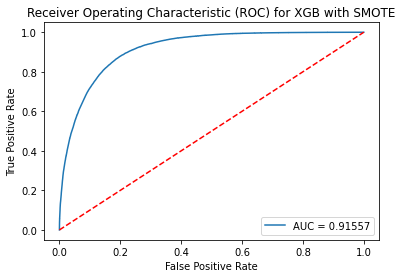

In [49]:
y_pred_ = best_xgb_model.predict_proba(x_val)[:,1]
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_val,y_pred_smote_)
roc_auc = auc(fpr,tpr)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.5f}')
plt.plot([0, 1], [0, 1], 'r--') # The diagonal line (random guessing)
plt.title('Receiver Operating Characteristic (ROC) for XGB with SMOTE')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

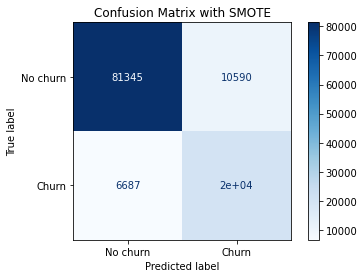

In [31]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val, y_pred_smote)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix with SMOTE")
plt.show()

# Using Optuna

In [52]:
import optuna
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

x_tune = x_train.sample(frac=0.15, random_state=42)
y_tune = y_train.loc[x_tune.index]


def objective(trial):

    params = {
        'xgb__max_depth': trial.suggest_int('max_depth', 3, 10),
        'xgb__learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1),
        'xgb__n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'xgb__subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'xgb__colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'xgb__min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'xgb__gamma': trial.suggest_float('gamma', 0, 5),
    }

    model = Pipeline(steps=[
        ('ct', ct),
        ('xgb', XGBClassifier(
            scale_pos_weight=ratio,
            tree_method='hist',
            eval_metric='auc'
        ))
    ])

    model.set_params(**params)

    score = cross_val_score(
        model,
        x_tune,
        y_tune,
        cv=3,
        scoring="roc_auc"
    ).mean()

    return score


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)


best_params = {f"xgb__{k}": v for k, v in study.best_params.items()}

pipeline1.set_params(**best_params)

pipeline1.fit(x_train, y_train)

y_val_pred = pipeline1.predict(x_val)
y_val_pred_o = pipeline1.predict_proba(x_val)[:, 1]
y_val_proba1 = pipeline1.predict_proba(test_df)[:, 1]

[I 2026-05-20 02:12:33,303] A new study created in memory with name: no-name-a8e22dee-51c0-4b25-9dd2-e43173200f5e


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-05-20 02:12:43,027] Trial 0 finished with value: 0.9134355905232804 and parameters: {'max_depth': 9, 'learning_rate': 0.08068199360702324, 'n_estimators': 831, 'subsample': 0.7776938036343579, 'colsample_bytree': 0.6440886006377983, 'min_child_weight': 4, 'gamma': 4.535762681216874}. Best is trial 0 with value: 0.9134355905232804.
[I 2026-05-20 02:12:50,738] Trial 1 finished with value: 0.91264673346648 and parameters: {'max_depth': 9, 'learning_rate': 0.09535550752129521, 'n_estimators': 498, 'subsample': 0.5812354278189087, 'colsample_bytree': 0.6157312468516976, 'min_child_weight': 6, 'gamma': 4.9052883450767295}. Best is trial 0 with value: 0.9134355905232804.
[I 2026-05-20 02:13:05,822] Trial 2 finished with value: 0.9144919849391783 and parameters: {'max_depth': 5, 'learning_rate': 0.01130403402343332, 'n_estimators': 750, 'subsample': 0.559210167407513, 'colsample_bytree': 0.6853190897174627, 'min_child_weight': 4, 'gamma': 4.315691925695871}. Best is trial 2 with value:

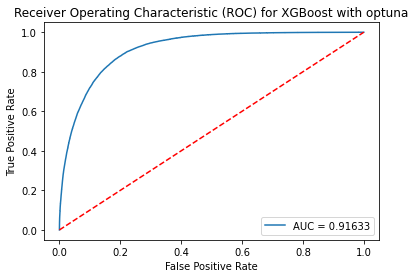

In [53]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_val,y_val_pred_o)
roc_auc = auc(fpr,tpr)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.5f}')
plt.plot([0, 1], [0, 1], 'r--') # The diagonal line (random guessing)
plt.title('Receiver Operating Characteristic (ROC) for XGBoost with optuna')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

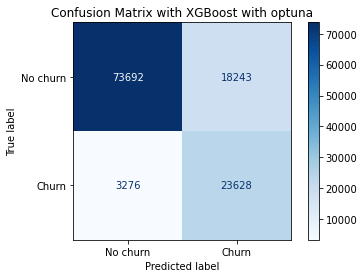

In [54]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
cm = confusion_matrix(y_val, y_val_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No churn', 'Churn'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix with XGBoost with optuna")
plt.show()

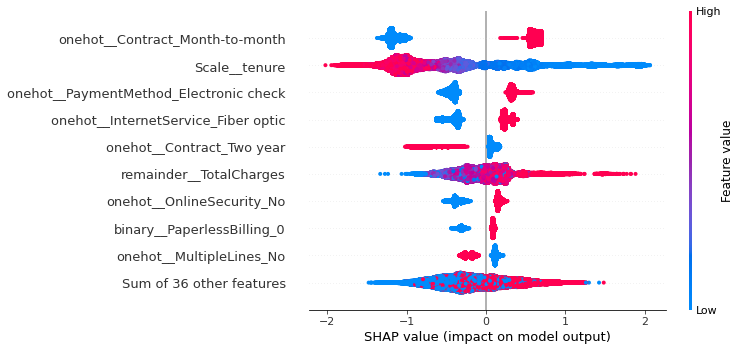

In [87]:
import shap
# transform validation data
x_val_transformed = pipeline1.named_steps['ct'].transform(x_val)

# feature names
feature_names = pipeline1.named_steps['ct'].get_feature_names_out()

# dataframe
x_val_df = pd.DataFrame(
    x_val_transformed,
    columns=feature_names
)
xgb_model = pipeline1.named_steps['xgb']
# shap
explainer = shap.TreeExplainer(xgb_model)

shap_values = explainer(x_val_df)

shap.plots.beeswarm(shap_values)

1.onehot__Contract_Month-to-month (The Top Predictor)

Actual Business Reason: Month-to-month customers have no switching costs. They can leave the moment a competitor offers a better deal or if they experience a single bad customer support interaction. They lack long-term friction or commitment.
2 Also i can see that features are interacting. for example, Month-to-Month Contract nd Electronic Check, the customer who has both are actively think about how much money they are giving this company every 30 day.And because they are month-to-month, the exact moment they ask themselves, "Is this service really worth it?" the door is wide open for them to walk away instantly.

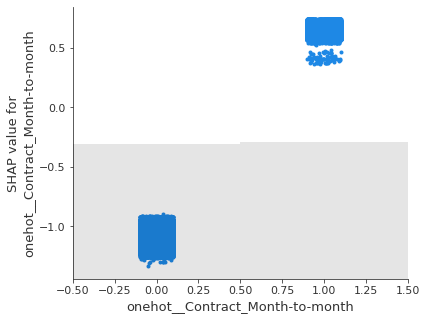

In [84]:
#dependence plot
#A dependence scatter plot shows the effect a single feature has on the predictions made by the model.
#This means there are non-linear interaction effects in the model between feature
shap.plots.scatter(shap_values[:,"onehot__Contract_Month-to-month"])

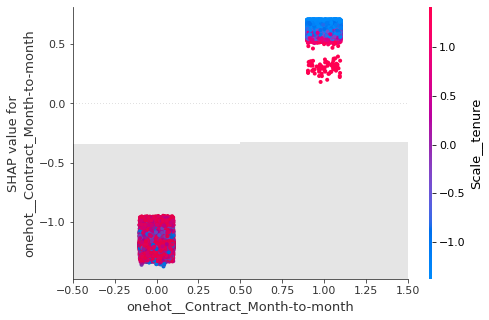

In [89]:
#To show which feature may be driving these interaction effects we can color scatter plot by another feature. 
#If we pass the entire shap_values  to the color parameter then the scatter plot attempts to pick out the feature column with the strongest interaction
shap.plots.scatter(shap_values[:,"onehot__Contract_Month-to-month"], color= shap_values)

# CatBoostClassifier

The first algorithm we will try is Cat Boost, an open-source ML library. It is an ensemble algorithm that comes under boosting category created by Yandex, which can internally handle both missing and categorical values. We will use cat boost with a scale pos weight value of 5. Also there is no need to convert the numerical values to categorical.

In [67]:
from catboost import CatBoostClassifier
# Identify categorical features
cat_features = x_train.select_dtypes(include=['object']).columns.tolist()

model = CatBoostClassifier(scale_pos_weight = 5,iterations=1000, eval_metric='AUC', verbose=100)

# Passing the cat_features 
model_cat = model.fit(x_train, y_train, 
          cat_features=cat_features, 
          eval_set=(x_val, y_val))

y_val_preds = model_cat.predict(x_val) 
y_val_preds_ = model_cat.predict_proba(x_val)[:, 1]
y_test_probs = model_cat.predict_proba(test_df)[:, 1]



Learning rate set to 0.145255
0:	test: 0.8853586	best: 0.8853586 (0)	total: 976ms	remaining: 16m 15s
100:	test: 0.9147670	best: 0.9147670 (100)	total: 1m 8s	remaining: 10m 11s
200:	test: 0.9161447	best: 0.9161468 (198)	total: 2m 29s	remaining: 9m 55s
300:	test: 0.9165308	best: 0.9165308 (300)	total: 3m 42s	remaining: 8m 35s
400:	test: 0.9167422	best: 0.9167440 (399)	total: 4m 56s	remaining: 7m 22s
500:	test: 0.9168557	best: 0.9168557 (500)	total: 6m 10s	remaining: 6m 8s
600:	test: 0.9168666	best: 0.9168841 (554)	total: 7m 23s	remaining: 4m 54s
700:	test: 0.9168745	best: 0.9169006 (657)	total: 8m 42s	remaining: 3m 42s
800:	test: 0.9168436	best: 0.9169006 (657)	total: 9m 58s	remaining: 2m 28s
900:	test: 0.9168186	best: 0.9169006 (657)	total: 11m 15s	remaining: 1m 14s
999:	test: 0.9168040	best: 0.9169006 (657)	total: 12m 32s	remaining: 0us

bestTest = 0.9169006122
bestIteration = 657

Shrink model to first 658 iterations.


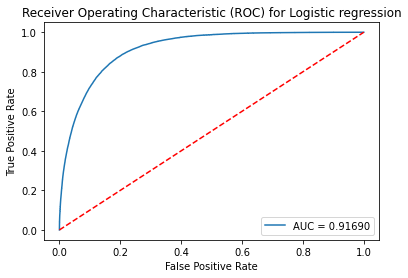

In [51]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_val,y_val_preds_)
roc_auc = auc(fpr,tpr)
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.5f}')
plt.plot([0, 1], [0, 1], 'r--') # The diagonal line (random guessing)
plt.title('Receiver Operating Characteristic (ROC) for Logistic regression')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.show()

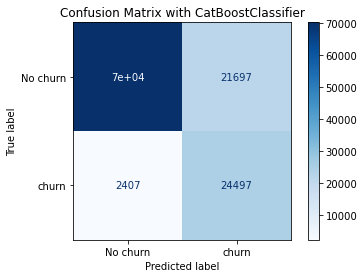

In [43]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_val, y_val_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No churn', 'churn'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix with CatBoostClassifier")
plt.show()



In [ ]:
The CatBoost confusion matrix is the best overall choice here

In [44]:
# 1. Average the validation probabilities from Optuna-XGBoost and CatBoost
final_val_proba = (y_val_pred_o + y_val_preds_) / 2

# 2. Check your new blended ROC-AUC Score
from sklearn.metrics import roc_auc_score
blended_auc = roc_auc_score(y_val, final_val_proba)
print(f"Blended Ensemble ROC-AUC: {blended_auc:.5f}")

Blended Ensemble ROC-AUC: 0.91694
